In [1]:
import pandas as pd
import numpy as np
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk import word_tokenize
from sklearn.metrics import confusion_matrix, classification_report 
from sklearn.model_selection import train_test_split

In [2]:
df =  pd.read_csv('spam.csv', encoding='latin1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df = df[['v1', 'v2']]
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


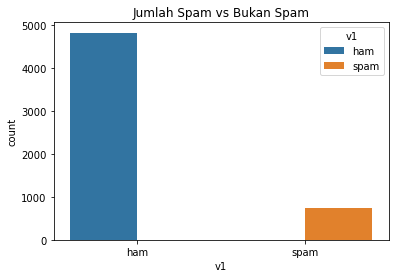

<Figure size 720x720 with 0 Axes>

In [4]:
plt.title('Jumlah Spam vs Bukan Spam')
sns.countplot(x='v1', hue='v1', data=df)
plt.figure(figsize=(10,10))
plt.show()

# Cleaning

In [5]:
def bersih_text(text):
    text = text.lower() #case folding
    text = re.sub('https?://\S+|www\.\S+', '', text) #hapus url
    text = re.sub('<.*?>+', '', text) #hapus tag
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text) #hapus tanda baca
    text = re.sub('\d+', '', text) #menghapus angka 0-9
    text = re.sub("\s+"," ",text).strip() #menghapus white space yg lebih dari 1
    text = text.replace("\n", " ") 
    text = " ".join(text.split())
    return text

df["v2"] = df["v2"].apply(bersih_text)

df.head()

,v1,v2
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final ...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [6]:
# nltk.download('punkt')

def tokennization(text):
    return word_tokenize(text)

df["v2"] = df["v2"].apply(tokennization)
df.head()

,v1,v2
0,ham,"[go, until, jurong, point, crazy, available, o..."
1,ham,"[ok, lar, joking, wif, u, oni]"
2,spam,"[free, entry, in, a, wkly, comp, to, win, fa, ..."
3,ham,"[u, dun, say, so, early, hor, u, c, already, t..."
4,ham,"[nah, i, dont, think, he, goes, to, usf, he, l..."


In [7]:
# nltk.download("stopwords")
from nltk.corpus import stopwords

list_stopwords = stopwords.words("english")

def stopwords_removal(text):
    return [word for word in text if word not in list_stopwords]

df["v2"] = df["v2"].apply(stopwords_removal)
df.head()

,v1,v2
0,ham,"[go, jurong, point, crazy, available, bugis, n..."
1,ham,"[ok, lar, joking, wif, u, oni]"
2,spam,"[free, entry, wkly, comp, win, fa, cup, final,..."
3,ham,"[u, dun, say, early, hor, u, c, already, say]"
4,ham,"[nah, dont, think, goes, usf, lives, around, t..."


In [8]:
df["v2"] = [" ".join(map(str, i)) for i in df["v2"]]
df.head()

,v1,v2
0,ham,go jurong point crazy available bugis n great ...
1,ham,ok lar joking wif u oni
2,spam,free entry wkly comp win fa cup final tkts st ...
3,ham,u dun say early hor u c already say
4,ham,nah dont think goes usf lives around though


In [9]:
df = df.rename(columns={'v1': 'Target', 'v2': 'Email'})

df.head()

,Target,Email
0,ham,go jurong point crazy available bugis n great ...
1,ham,ok lar joking wif u oni
2,spam,free entry wkly comp win fa cup final tkts st ...
3,ham,u dun say early hor u c already say
4,ham,nah dont think goes usf lives around though


In [ ]:
df['Target'] = df['Target'].map({'ham': 0, 'spam': 1})

df.head()

,Target,Email
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry wkly comp win fa cup final tkts st ...
3,0,u dun say early hor u c already say
4,0,nah dont think goes usf lives around though


# Data Splitting

In [ ]:
X = df['Email'].values
y = df['Target'].values

X

array(['go jurong point crazy available bugis n great world la e buffet cine got amore wat',
       'ok lar joking wif u oni',
       'free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply overs',
       ..., 'pity mood soany suggestions',
       'guy bitching acted like id interested buying something else next week gave us free',
       'rofl true name'], dtype=object)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

# Tf-idf

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix_train = tfidf.fit_transform(X_train)
tfidf_matrix_valid= tfidf.transform(X_test)

tfidf_matrix_train.shape

(4457, 7169)

# Data Modeling

In [ ]:
from sklearn.metrics import accuracy_score

def classif_report(y_test, y_pred):
  print(classification_report(y_test, y_pred))

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(tfidf_matrix_train, y_train)
y_pred_log=lr.predict(tfidf_matrix_valid)
classif_report(y_test, y_pred_log)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       966
           1       0.95      0.68      0.79       149

    accuracy                           0.95      1115
   macro avg       0.95      0.84      0.88      1115
weighted avg       0.95      0.95      0.95      1115



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(tfidf_matrix_train, y_train)
y_pred_dt = dt.predict(tfidf_matrix_valid)
print(classif_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       966
           1       0.87      0.76      0.81       149

    accuracy                           0.95      1115
   macro avg       0.92      0.87      0.89      1115
weighted avg       0.95      0.95      0.95      1115

None


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(tfidf_matrix_train, y_train)
y_pred_rf = rf.predict(tfidf_matrix_valid)
print(classif_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

None


## SVC

In [ ]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(tfidf_matrix_train, y_train)
y_pred_svc= svc.predict(tfidf_matrix_valid)
classif_report(y_test, y_pred_svc)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.97      0.82      0.89       149

    accuracy                           0.97      1115
   macro avg       0.97      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [26]:
# Perbandingan hasil semua model
from sklearn.metrics import accuracy_score

model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "SVC"]
predictions  = [y_pred_log, y_pred_dt, y_pred_rf, y_pred_svc]

print("=" * 56)
print("  PERBANDINGAN MODEL — KLASIFIKASI EMAIL SPAM")
print("=" * 56)
print(f"  {"Model":<22} {"Accuracy":>10}")
print("-" * 56)
for name, pred in zip(model_names, predictions):
    acc = accuracy_score(y_test, pred)
    print(f"  {name:<22} {acc:>10.4f}")
print("-" * 56)

print()
for name, pred in zip(model_names, predictions):
    print(f"--- {name} ---")
    print(classification_report(y_test, pred))


  PERBANDINGAN MODEL — KLASIFIKASI EMAIL SPAM
  Model                      Accuracy
--------------------------------------------------------
  Logistic Regression          0.9534
  Decision Tree                0.9525
  Random Forest                0.9686
  SVC                          0.9677
--------------------------------------------------------

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       966
           1       0.95      0.68      0.79       149

    accuracy                           0.95      1115
   macro avg       0.95      0.84      0.88      1115
weighted avg       0.95      0.95      0.95      1115

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       966
           1       0.87      0.76      0.81       149

    accuracy                           0.95      1115
   macro avg       0.92      0.87      0.89      1115
